# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Exploratory Data Analysis

In [2]:
df = pd.read_csv("BitcoinHeistData.csv")

In [3]:
df.shape

(2916697, 10)

In [4]:
df.head()

,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.008333,1,0,2,100050000.0,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.000244,1,0,1,100000000.0,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.000000,1,0,2,200000000.0,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.003906,1,0,2,71200000.0,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.072848,456,0,1,200000000.0,princetonLocky


In [5]:
df.describe()

,year,day,length,weight,count,looped,neighbors,income
count,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06
mean,2.014475e+03,1.814572e+02,4.500859e+01,5.455192e-01,7.216446e+02,2.385067e+02,2.206516e+00,4.464889e+09
std,2.257398e+00,1.040118e+02,5.898236e+01,3.674255e+00,1.689676e+03,9.663217e+02,1.791877e+01,1.626860e+11
min,2.011000e+03,1.000000e+00,0.000000e+00,3.606469e-94,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+07
25%,2.013000e+03,9.200000e+01,2.000000e+00,2.148438e-02,1.000000e+00,0.000000e+00,1.000000e+00,7.428559e+07
50%,2.014000e+03,1.810000e+02,8.000000e+00,2.500000e-01,1.000000e+00,0.000000e+00,2.000000e+00,1.999985e+08
75%,2.016000e+03,2.710000e+02,1.080000e+02,8.819482e-01,5.600000e+01,0.000000e+00,2.000000e+00,9.940000e+08
max,2.018000e+03,3.650000e+02,1.440000e+02,1.943749e+03,1.449700e+04,1.449600e+04,1.292000e+04,4.996440e+13


In [6]:
df["label"].value_counts()

label
white                          2875284
paduaCryptoWall                  12390
montrealCryptoLocker              9315
princetonCerber                   9223
princetonLocky                    6625
montrealCryptXXX                  2419
montrealNoobCrypt                  483
montrealDMALockerv3                354
montrealDMALocker                  251
montrealSamSam                      62
montrealCryptoTorLocker2015         55
montrealGlobeImposter               55
montrealGlobev3                     34
montrealGlobe                       32
montrealWannaCry                    28
montrealRazy                        13
montrealAPT                         11
paduaKeRanger                       10
montrealFlyper                       9
montrealXTPLocker                    8
montrealVenusLocker                  7
montrealCryptConsole                 7
montrealXLockerv5.0                  7
montrealEDA2                         6
montrealJigSaw                       4
paduaJigsaw        

In [7]:
categorical_cols = df.select_dtypes(include="object").columns

In [8]:
numerical_cols = df.select_dtypes(include="number").columns

In [9]:
df.isnull().sum()

address      0
year         0
day          0
length       0
weight       0
count        0
looped       0
neighbors    0
income       0
label        0
dtype: int64

In [10]:
df["address"].nunique()

2631095

In [11]:
old_df = df.copy()

# Feature Engineering

In [12]:
df.drop(columns=["address", "year", "day"], axis=1, inplace=True)

In [13]:
for col in df.columns[:-1]:
    df[col] = df[col]

In [14]:
X = df.drop(columns=["label"])
y = df["label"]

In [15]:
X.columns

Index(['length', 'weight', 'count', 'looped', 'neighbors', 'income'], dtype='object')

In [16]:
df.head()

,length,weight,count,looped,neighbors,income,label
0,18,0.008333,1,0,2,100050000.0,princetonCerber
1,44,0.000244,1,0,1,100000000.0,princetonLocky
2,0,1.000000,1,0,2,200000000.0,princetonCerber
3,72,0.003906,1,0,2,71200000.0,princetonCerber
4,144,0.072848,456,0,1,200000000.0,princetonLocky


## Number of Instances

In [17]:
new_df = pd.DataFrame()
grouped = df.groupby("label")

In [18]:
new_df["num_of_instances"] = grouped.size()

## Average

In [19]:
df.columns

Index(['length', 'weight', 'count', 'looped', 'neighbors', 'income', 'label'], dtype='object')

In [20]:
for col in X.columns:
    new_df[f"{col}_avg"] = grouped[col].mean()

In [21]:
new_df.shape

(29, 7)

In [22]:
new_df.head()

,num_of_instances,length_avg,weight_avg,count_avg,looped_avg,neighbors_avg,income_avg
label,,,,,,,
montrealAPT,11,67.636364,0.707728,2047.000000,734.090909,2.545455,3.719873e+08
montrealComradeCircle,1,144.000000,0.051214,1241.000000,0.000000,2.000000,2.033200e+08
montrealCryptConsole,7,43.428571,0.593306,831.714286,0.000000,2.000000,4.546334e+07
montrealCryptXXX,2419,47.447706,0.367505,791.848284,61.022323,2.011988,1.355343e+08
montrealCryptoLocker,9315,30.674396,0.888878,308.328824,100.981535,2.885346,1.840825e+09


## Standard Deviation

In [23]:
for col in X.columns:
    new_df[f"{col}_std"] = grouped[col].agg(np.std).fillna(0)

/tmp/ipykernel_34624/178835755.py:2: FutureWarning: The provided callable <function std at 0x771d4bb72f20> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  new_df[f"{col}_std"] = grouped[col].agg(np.std).fillna(0)
/tmp/ipykernel_34624/178835755.py:2: FutureWarning: The provided callable <function std at 0x771d4bb72f20> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  new_df[f"{col}_std"] = grouped[col].agg(np.std).fillna(0)
/tmp/ipykernel_34624/178835755.py:2: FutureWarning: The provided callable <function std at 0x771d4bb72f20> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  new_df[f"{col}_std"] = grouped[col].agg(np.std)

## Minimum

In [24]:
for col in X.columns:
    new_df[f"{col}_min"] = grouped[col].min()

## Maximum

In [25]:
for col in X.columns:
    new_df[f"{col}_max"] = grouped[col].max()

In [26]:
new_df = new_df.reset_index()
new_df.head()

,label,num_of_instances,length_avg,weight_avg,count_avg,looped_avg,neighbors_avg,income_avg,length_std,weight_std,...,count_min,looped_min,neighbors_min,income_min,length_max,weight_max,count_max,looped_max,neighbors_max,income_max
0,montrealAPT,11,67.636364,0.707728,2047.000000,734.090909,2.545455,3.719873e+08,73.145434,0.600596,...,1,0,1,57142857.0,144,1.666667,8076,8073,6,1.088599e+09
1,montrealComradeCircle,1,144.000000,0.051214,1241.000000,0.000000,2.000000,2.033200e+08,0.000000,0.000000,...,1241,0,2,203320001.0,144,0.051214,1241,0,2,2.033200e+08
2,montrealCryptConsole,7,43.428571,0.593306,831.714286,0.000000,2.000000,4.546334e+07,68.747987,0.410909,...,1,0,2,30000000.0,144,1.000000,3191,0,2,5.030000e+07
3,montrealCryptXXX,2419,47.447706,0.367505,791.848284,61.022323,2.011988,1.355343e+08,58.187904,0.434143,...,1,0,1,30000000.0,144,3.458951,9262,8489,15,1.080000e+09
4,montrealCryptoLocker,9315,30.674396,0.888878,308.328824,100.981535,2.885346,1.840825e+09,50.731602,1.555608,...,1,0,1,30000000.0,144,31.108593,6423,6418,79,4.450000e+11


# Data Preprocessing

## Undersampling

In [27]:
black_rows = df[df["label"] != "white"]

In [28]:
white_sample = df[df["label"] == "white"].sample(n=158587, random_state=42)

In [29]:
sampled_df = pd.concat([black_rows, white_sample]).sample(frac=1, random_state=50)
sampled_df.head()

,length,weight,count,looped,neighbors,income,label
526724,14,0.003906,1,0,2,3.216000e+09,white
2825235,144,0.196970,1805,0,2,5.578352e+07,white
7558,14,0.015625,1,0,2,6.355311e+08,montrealCryptoLocker
1141393,6,1.000000,1,0,2,2.925100e+08,white
1484054,142,0.065711,2568,0,2,1.360000e+08,white


## Label Encoding

We do label encoding of:
> * White label: 0
> * Ransomware: 1

In [30]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

sampled_df["label"] = label_encoder.fit_transform(sampled_df["label"])

sampled_df["label"] = sampled_df["label"].apply(
    lambda x: 0 if x == label_encoder.transform(["white"])[0] else 1
)

sampled_df["label"]

526724     0
2825235    0
7558       1
1141393    0
1484054    0
          ..
1363905    0
1934713    0
2481475    0
2039010    0
880386     0
Name: label, Length: 200000, dtype: int64

## Z-score Anomaly Filteration

In [31]:
z_score_df = pd.DataFrame()
for col in sampled_df.columns:
    z_score_df[f"{col}_z_score"] = (
        sampled_df[col] - sampled_df[col].mean()
    ) / sampled_df[col].std()
z_score_df.head()

,length_z_score,weight_z_score,count_z_score,looped_z_score,neighbors_z_score,income_z_score,label_z_score
526724,-0.513441,-0.114174,-0.424426,-0.234473,-0.009561,-0.004920,-0.511015
2825235,1.695481,-0.075626,0.677535,-0.234473,-0.009561,-0.028981,-0.511015
7558,-0.513441,-0.111834,-0.424426,-0.234473,-0.009561,-0.024567,1.956881
1141393,-0.649374,0.084711,-0.424426,-0.234473,-0.009561,-0.027178,-0.511015
1484054,1.661498,-0.101834,1.143608,-0.234473,-0.009561,-0.028370,-0.511015


In [32]:
import pandas as pd

filtered_df = z_score_df[
    z_score_df.apply(lambda row: all(-3 <= val <= 3 for val in row), axis=1)
]

filtered_df.head()

,length_z_score,weight_z_score,count_z_score,looped_z_score,neighbors_z_score,income_z_score,label_z_score
526724,-0.513441,-0.114174,-0.424426,-0.234473,-0.009561,-0.004920,-0.511015
2825235,1.695481,-0.075626,0.677535,-0.234473,-0.009561,-0.028981,-0.511015
7558,-0.513441,-0.111834,-0.424426,-0.234473,-0.009561,-0.024567,1.956881
1141393,-0.649374,0.084711,-0.424426,-0.234473,-0.009561,-0.027178,-0.511015
1484054,1.661498,-0.101834,1.143608,-0.234473,-0.009561,-0.028370,-0.511015


## Train Test Split

> Training data: 66%
> Test data: 33%

In [33]:
X = sampled_df.drop("label", axis=1)
y = (sampled_df["label"] > 0).astype("int")

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.33, shuffle=True
)

## Standardization

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Training

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)


param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy during CV:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Evaluation

In [ ]:
val_predictions = best_rf.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)
print(f"Validation Accuracy: {val_accuracy}")

2063/2063 [==============================] - 3s 1ms/step - loss: 0.4458 - accuracy: 0.7981


In [ ]:
test_predictions = best_rf.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Test Accuracy: {test_accuracy}")

Test Loss: 0.4457826316356659
Test Accuracy: 0.7981212139129639


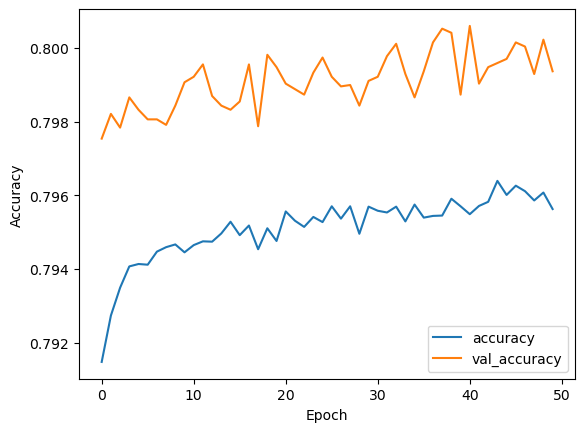

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(range(X_train.shape[1]), best_rf.feature_importances_, align="center")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.show()

In [ ]:
print(classification_report(y_test, test_predictions))

2063/2063 [==============================] - 2s 1ms/step
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     52447
           1       0.61      0.05      0.09     13553

    accuracy                           0.80     66000
   macro avg       0.70      0.52      0.49     66000
weighted avg       0.76      0.80      0.72     66000

